## EDA: Precipitação — `precipitacao.csv`

Caminho do dataset:
`/Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /data/precipitacao.csv`

Objetivo: caracterizar a série (cobertura temporal, estatísticas, outliers, sazonalidade), localização dos pontos, frequência e lacunas; exportar resumos — tudo dentro de `EDA`.


### 1) Setup de bibliotecas e configuração de paths


In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

DATA_FILE = Path("/Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /data/precipitacao.csv")
assert DATA_FILE.exists(), f"CSV not found: {DATA_FILE}"

pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print(f"Using file: {DATA_FILE}")


Using file: /Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /data/precipitacao.csv


### 2) Leitura do CSV e preparação de colunas

#### 2.1 Explicação do código
- `parse_dates` para `data`.
- Tipos otimizados.
- Renomeação para nomes explícitos.
- Colunas derivadas: `year`, `month`, `site_id` e `site_label` (`codigo | y_x`).


In [2]:
parse_dates = ["data"]
df = pd.read_csv(
    DATA_FILE,
    parse_dates=parse_dates,
    dtype={
        "codigo": "string",
        "precipitacao_dia_mm": "float32",
        "nome": "string",
        "coord_x_m": "float32",
        "coord_y_m": "float32",
    },
)

# Renomear e derivar
rename_map = {
    "data": "date",
    "codigo": "station_code",
    "precipitacao_dia_mm": "prec_mm",
    "coord_x_m": "x_m",
    "coord_y_m": "y_m",
}
df = df.rename(columns=rename_map).sort_values("date").reset_index(drop=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# site_id e label legível
df["site_id"] = df["y_m"].round(2).astype(str) + "_" + df["x_m"].round(2).astype(str)
df["site_label"] = df["station_code"].astype(str) + " | " + df["site_id"]

print(df.head()); df.info()


        date station_code  prec_mm                         nome        x_m        y_m  year  month  \
0 1979-10-01      21C/01U    0.000              SACAVÉM DE CIMA 114863.477 203397.938  1979     10   
1 1979-10-01      18D/01C    0.000                   ASSEICEIRA 131181.531 258754.547  1979     10   
2 1979-10-01     17E/03UG    0.000                AZÓIA DE CIMA 147380.125 264929.219  1979     10   
3 1979-10-01      16H/01C    0.000  BARRAGEM DE CASTELO DO BODE 183910.016 285731.188  1979     10   
4 1979-10-01      20E/01C    0.000            BARRAGEM DE MAGOS 151370.000 224830.000  1979     10   

               site_id                      site_label  
0  203397.94_114863.48   21C/01U | 203397.94_114863.48  
1  258754.55_131181.53   18D/01C | 258754.55_131181.53  
2  264929.22_147380.12  17E/03UG | 264929.22_147380.12  
3   285731.2_183910.02    16H/01C | 285731.2_183910.02  
4    224830.0_151370.0     20E/01C | 224830.0_151370.0  
<class 'pandas.core.frame.DataFrame'>
RangeIn

### 3) Cobertura temporal, frequência e lacunas por ponto

#### 3.1 Explicação do código
- Estatísticas descritivas de `prec_mm`.
- Inferir frequência por `site_id` e calcular períodos em falta (diário.
- Duplicados por `date`×`site_id`.


In [3]:
from pandas.tseries.frequencies import to_offset

print(df[["prec_mm"]].describe(percentiles=[0.5, 0.9, 0.99]))

dups = df[df.duplicated(["date", "site_id"], keep=False)]
print(f"Duplicate timestamps (per site): {dups.shape[0]}")

# Frequência e lacunas (assumindo precipitação diária)
from collections import Counter

def compute_missing_for_site_daily(df_site: pd.DataFrame) -> tuple[int, list]:
    if df_site.empty:
        return 0, []
    start = df_site["date"].min().normalize()
    end = df_site["date"].max().normalize()
    full_range = pd.date_range(start=start, end=end, freq="D")
    missing = full_range.difference(df_site["date"].dt.normalize().unique())
    return int(missing.size), [str(x.date()) for x in list(missing[:5])]

site_rows = []
for site_id, df_s in df.groupby("site_id"):
    missing_count, missing_first_5 = compute_missing_for_site_daily(df_s)
    site_label = df_s["site_label"].iloc[0]
    site_rows.append({
        "site_id": site_id,
        "site_label": site_label,
        "freq_label": "daily",
        "missing_count": missing_count,
        "missing_first_5": ", ".join(missing_first_5),
    })

site_frequency_summary = pd.DataFrame(site_rows)
display(site_frequency_summary.head())


          prec_mm
count 1096516.000
mean        1.271
std         4.821
min         0.000
50%         0.000
90%         2.800
99%        24.300
max       264.600
Duplicate timestamps (per site): 0


,site_id,site_label,freq_label,missing_count,missing_first_5
0,172472.16_123280.21,22C/02UG | 172472.16_123280.21,daily,752,"2010-10-01, 2010-10-02, 2010-10-03, 2010-10-04..."
1,172723.42_168271.45,22G/01UG | 172723.42_168271.45,daily,447,"2012-10-01, 2012-10-02, 2012-10-03, 2012-10-04..."
2,179501.4_151088.38,22E/01UG | 179501.4_151088.38,daily,447,"2012-10-01, 2012-10-02, 2012-10-03, 2012-10-04..."
3,179748.0_157884.0,22F/03C | 179748.0_157884.0,daily,447,"2012-10-01, 2012-10-02, 2012-10-03, 2012-10-04..."
4,188713.0_106897.0,22B/01C | 188713.0_106897.0,daily,386,"2010-03-17, 2010-07-25, 2010-07-26, 2010-07-27..."


### 4) Outliers e gráficos

#### 4.1 Explicação do código
- Deteção IQR + Z-score para `prec_mm`.
- Gráficos agregados (todas as estações) e por estação com dropdown.


prec_mm outliers: 247413


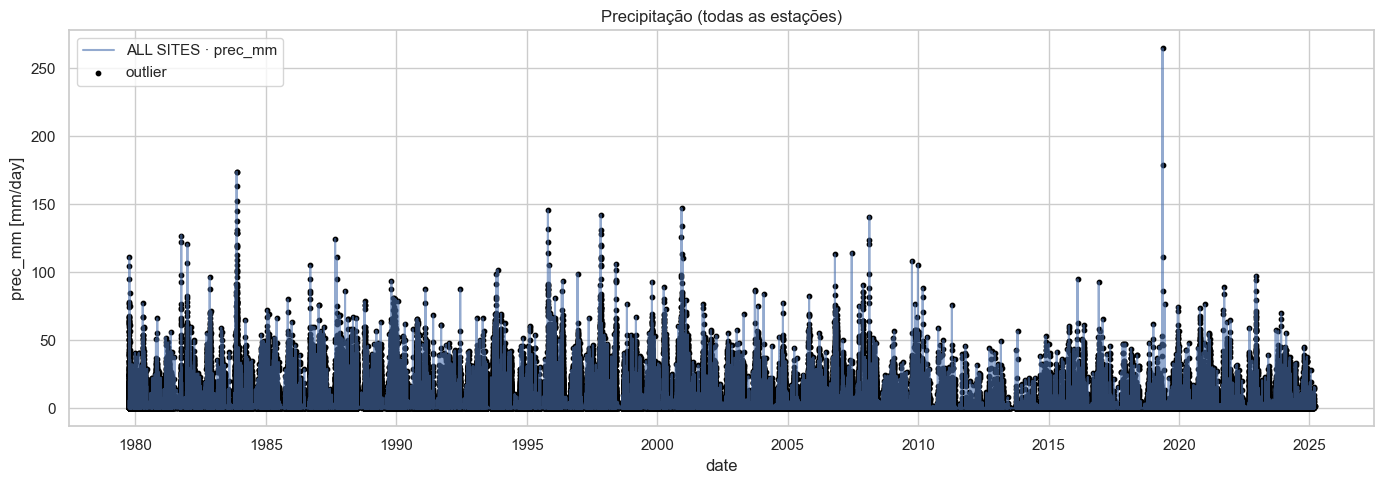

Dropdown(description='site:', options=(('22C/02UG | 172472.16_123280.21', '172472.16_123280.21'), ('22G/01UG |…

Output()

In [ ]:
def detect_outliers_iqr(series: pd.Series, factor: float = 1.5) -> pd.Series:
    q1 = np.nanpercentile(series, 25)
    q3 = np.nanpercentile(series, 75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return (series < lower) | (series > upper)


def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    mu = np.nanmean(series)
    sigma = np.nanstd(series)
    if sigma == 0 or np.isnan(sigma):
        return pd.Series(False, index=series.index)
    z = (series - mu) / sigma
    return z.abs() > threshold

flags = detect_outliers_iqr(df["prec_mm"]) | detect_outliers_zscore(df["prec_mm"])
df["is_outlier_prec"] = flags
print(f"prec_mm outliers: {flags.sum()}")

# Gráfico agregado
plt.figure(figsize=(14,5))
plt.plot(df["date"], df["prec_mm"], alpha=0.6, label="ALL SITES · prec_mm")
plt.scatter(df.loc[flags, "date"], df.loc[flags, "prec_mm"], s=10, color="black", label="outlier")
plt.legend(); plt.xlabel("date"); plt.ylabel("prec_mm [mm/day]")
plt.title("Precipitação (todas as estações)")
plt.tight_layout(); plt.show()

# Dropdown por estação
import ipywidgets as widgets
from IPython.display import display, clear_output
stations = sorted(df["site_id"].unique())
map_label = df.groupby("site_id")["site_label"].first().to_dict()
opts = [(map_label[s], s) for s in stations]
out = widgets.Output(); dd = widgets.Dropdown(options=opts, value=stations[0], description="site:")

def plot_station(site_id: str):
    d = df[df["site_id"] == site_id].sort_values("date")
    lab = map_label.get(site_id, site_id)
    plt.figure(figsize=(14,5))
    plt.plot(d["date"], d["prec_mm"], label=lab)
    if "is_outlier_prec" in d.columns:
        m = d["is_outlier_prec"]
        plt.scatter(d.loc[m, "date"], d.loc[m, "prec_mm"], s=10, color="black", label="outlier")
    plt.legend(); plt.xlabel("date"); plt.ylabel("prec_mm [mm/day]")
    plt.title(f"Precipitação ({lab})")
    plt.tight_layout(); plt.show()

def on_change(c):
    if c["name"] == "value":
        with out:
            clear_output(wait=True)
            plot_station(c["new"]) 

dd.observe(on_change, names="value"); display(dd)
with out:
    plot_station(dd.value)
display(out)


### 5) Resumo por estação e export

#### 5.1 Explicação do código
- Tabela de localização (`site_id`, `site_label`, `x_m`, `y_m`) com nº de observações e intervalo temporal.
- Junta frequência e lacunas por estação.
- Exporta CSVs para `EDA /scripts/precipitacao/resources/`.


In [5]:
location_summary = (
    df.groupby(["site_id", "site_label", "y_m", "x_m"]).agg(
        n_obs=("date", "count"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        total_prec_mm=("prec_mm", "sum")
    ).reset_index()
)

location_summary = location_summary.merge(site_frequency_summary, on=["site_id", "site_label"], how="left")

display(location_summary.head())

from pathlib import Path
out_dir = Path("/Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /scripts/precipitacao/resources")
out_dir.mkdir(parents=True, exist_ok=True)

# Resumos gerais
general_stats = df[["prec_mm"]].describe().T
general_stats.loc["meta_unique_points", "count"] = location_summary.shape[0]

location_summary.to_csv(out_dir / "precip_location_summary.csv", index=False)
site_frequency_summary.to_csv(out_dir / "precip_frequency_gaps_by_site.csv", index=False)
general_stats.to_csv(out_dir / "precip_summary_stats.csv")

print(f"Saved summaries in: {out_dir}")


,site_id,site_label,y_m,x_m,n_obs,first_date,last_date,total_prec_mm,freq_label,missing_count,missing_first_5
0,172472.16_123280.21,22C/02UG | 172472.16_123280.21,172472.156,123280.211,15778,1979-10-01,2025-01-01,25276.400,daily,752,"2010-10-01, 2010-10-02, 2010-10-03, 2010-10-04..."
1,172723.42_168271.45,22G/01UG | 172723.42_168271.45,172723.422,168271.453,16156,1979-10-01,2025-03-15,18924.801,daily,447,"2012-10-01, 2012-10-02, 2012-10-03, 2012-10-04..."
2,179501.4_151088.38,22E/01UG | 179501.4_151088.38,179501.406,151088.375,16156,1979-10-01,2025-03-15,20760.500,daily,447,"2012-10-01, 2012-10-02, 2012-10-03, 2012-10-04..."
3,179748.0_157884.0,22F/03C | 179748.0_157884.0,179748.000,157884.000,16156,1979-10-01,2025-03-15,25533.600,daily,447,"2012-10-01, 2012-10-02, 2012-10-03, 2012-10-04..."
4,188713.0_106897.0,22B/01C | 188713.0_106897.0,188713.000,106897.000,16144,1979-10-01,2025-01-01,16363.100,daily,386,"2010-03-17, 2010-07-25, 2010-07-26, 2010-07-27..."


Saved summaries in: /Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /scripts/precipitacao/resources
